# Train Gaussian Process Emulators

In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd

import fates_calibration_library.utils as utils
import fates_calibration_library.clm_functions as clm
import fates_calibration_library.surface_data_functions as surface
import fates_calibration_library.emulator_functions as em

import tensorflow as tf
import gpflow

import matplotlib.pyplot as plt
import importlib

2025-07-18 10:17:51.833322: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-18 10:17:51.835030: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-18 10:17:51.860464: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-18 10:17:51.861223: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-18 10:17:54.483965: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

## Set Up
Load files, set up ensemble information

In [2]:
# dataset with land area 
land_frac_ds_file = os.path.join("/glade/derecho/scratch/afoster/archive",
                            "ctsm60SP_bigleaf_fullgrid/lnd/hist",
                            "ctsm60SP_bigleaf_fullgrid.clm2.h0.0001-02-01-00000.nc")

# surface file
surdat_dir = "/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/surfdata_esmf/ctsm5.4.0/"
surdat_2deg = os.path.join(surdat_dir, "surfdata_1.9x2.5_hist_2000_16pfts_c250617.nc")

pft_id_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/fates_pft_ids.yaml'
pft_ids = utils.get_config_file(pft_id_config)

# directories
mesh_dir = '/glade/work/afoster/FATES_calibration/mesh_files'
hist_dir = '/glade/work/afoster/FATES_calibration/history_files/compiled_files'
emulator_dir = '/glade/work/afoster/FATES_calibration/emulators'
fig_dir = '/glade/work/afoster/FATES_calibration/figures'
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'

# grab pft names
default_param = xr.open_dataset(os.path.join(param_dir,
                                             'fates_params_default_sci.1.85.1_api.40.0.0_crops.nc'))
all_pfts = [str(pft).replace("b'", "").replace("'", "").strip() for pft in default_param.fates_pftname.values]

# variables to emulate
calibration_vars = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF']

# test/train split
n_test = 50

In [3]:
surdat = surface.get_surdat(surdat_2deg)

In [4]:
# information about each ensemble
ens_dict = {'dompft':
            {'mesh_file': os.path.join(mesh_dir, 'dominant_grid_mesh.nc'),
             'land_mask_file': os.path.join(mesh_dir, 'dominant_grid.nc'),
             'ensemble_file': os.path.join(hist_dir, 'fates_dompft_annual_means.nc'),
             'lhc_key_file': os.path.join(param_dir, 'fates_lh', 'fates_lh_key.csv'),
             'pfts': [1, 2, 3, 12, 13, 14],
             'obs_df': os.path.join(mesh_dir, 'dominant_grid.csv'),
            }
           }

In [5]:
# choose ensemble
ensemble = 'dompft'

### Load Latin Hypercube Key

In [6]:
lhc_key = pd.read_csv(ens_dict[ensemble]['lhc_key_file'], index_col=[0])
lhc_key = lhc_key.drop(columns=['ensemble'])
param_names = lhc_key.columns
num_params = len(param_names)

### Load Dictionary of Potential Kernels

In [7]:
gp_kernels = em.build_kernel_dict(num_params)

2025-07-18 10:18:00.167160: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Train Emulators
Loop through each pft and variable to train and save emulators

Saving model to: /glade/work/afoster/FATES_calibration/emulators/BETT_GPP...


2025-07-18 10:21:16.110931: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'X' with dtype double and shape [?,20]
	 [[{{node X}}]]
2025-07-18 10:21:16.290499: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'serving_default_X' with dtype double and shape [?,20]
	 [[{{node serving_default_X}}]]


INFO:tensorflow:Assets written to: /glade/work/afoster/FATES_calibration/emulators/BETT_GPP/assets


INFO:tensorflow:Assets written to: /glade/work/afoster/FATES_calibration/emulators/BETT_GPP/assets


Saving validation plot to: /glade/work/afoster/FATES_calibration/figures/emulator_figs/BETT_GPP_emulator_validation.png


...

INFO:tensorflow:Assets written to: /glade/work/afoster/FATES_calibration/emulators/C4G_FSH/assets


Saving validation plot to: /glade/work/afoster/FATES_calibration/figures/emulator_figs/C4G_FSH_emulator_validation.png


Saving model to: /glade/work/afoster/FATES_calibration/emulators/C4G_EF...
INFO:tensorflow:Assets written to: /glade/work/afoster/FATES_calibration/emulators/C4G_EF/assets


2025-07-18 10:43:04.984348: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'X' with dtype double and shape [?,20]
	 [[{{node X}}]]
2025-07-18 10:43:05.019003: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'serving_default_X' with dtype double and shape [?,20]
	 [[{{node serving_default_X}}]]
INFO:tensorflow:Assets written to: /glade/work/afoster/FATES_calibration/emulators/C4G_EF/assets


Saving validation plot to: /glade/work/afoster/FATES_calibration/figures/emulator_figs/C4G_EF_emulator_validation.png


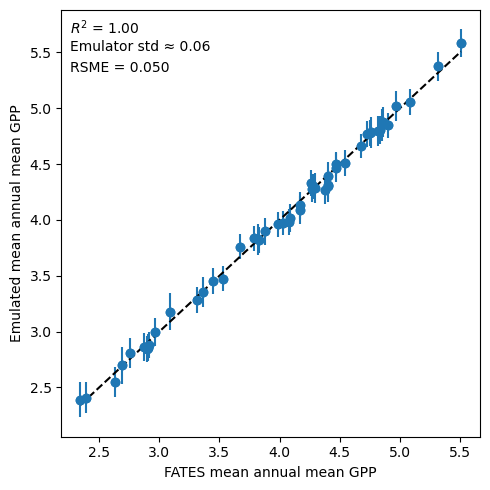

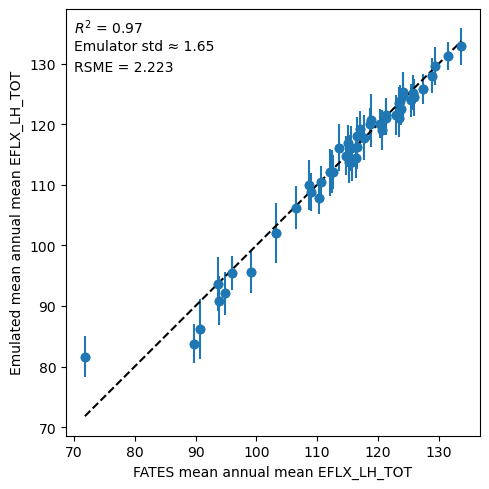

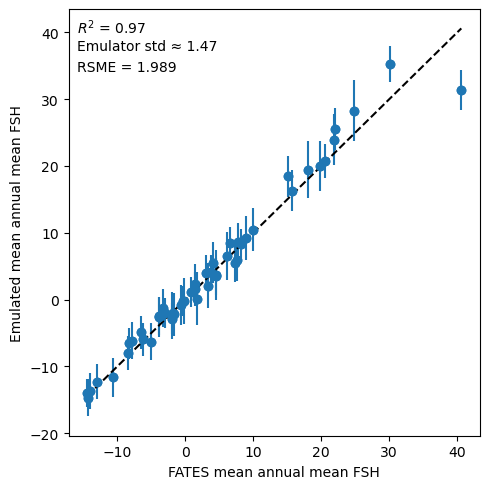

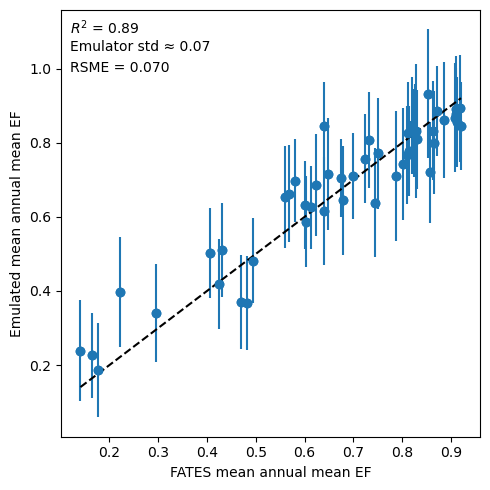

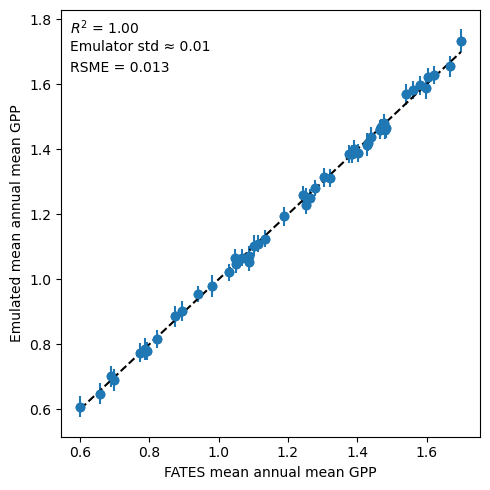

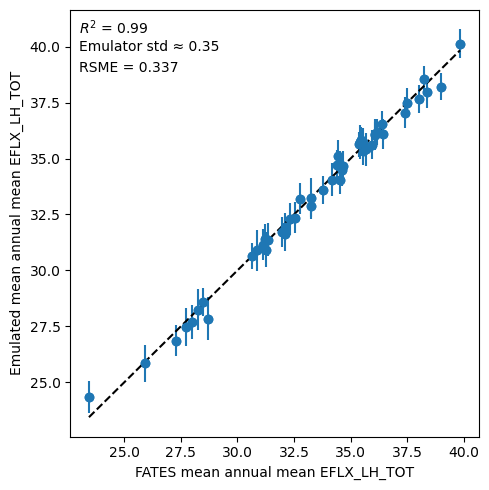

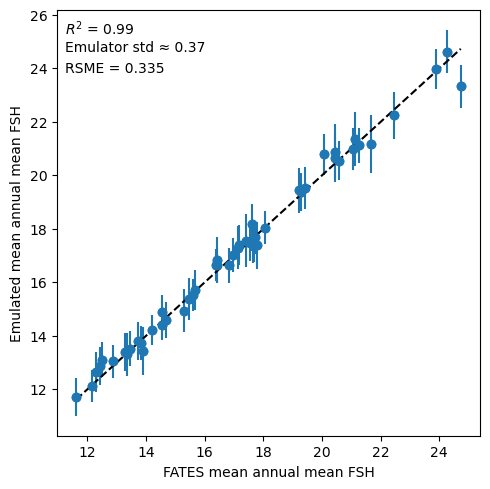

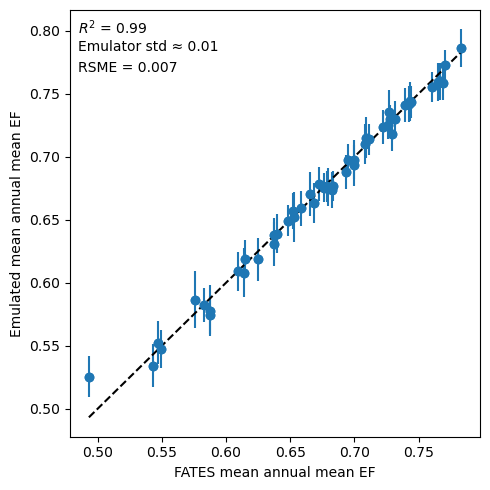

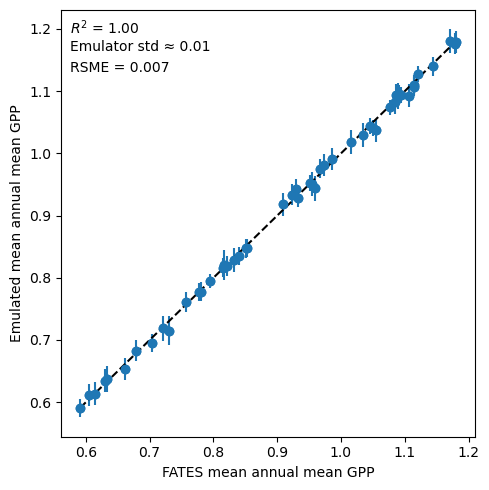

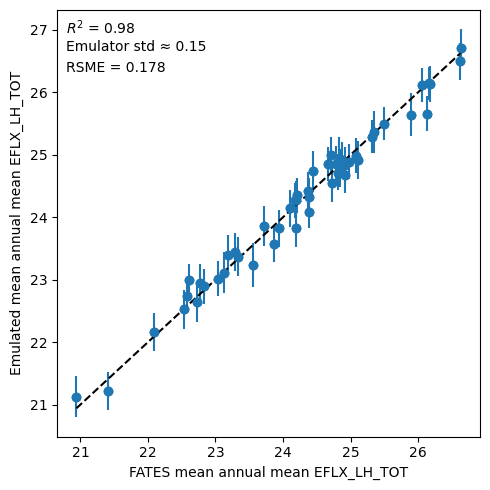

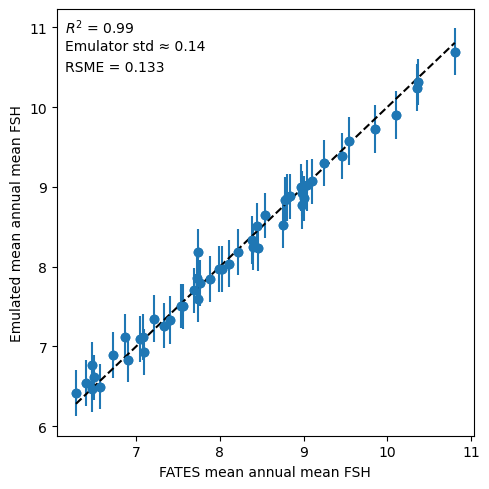

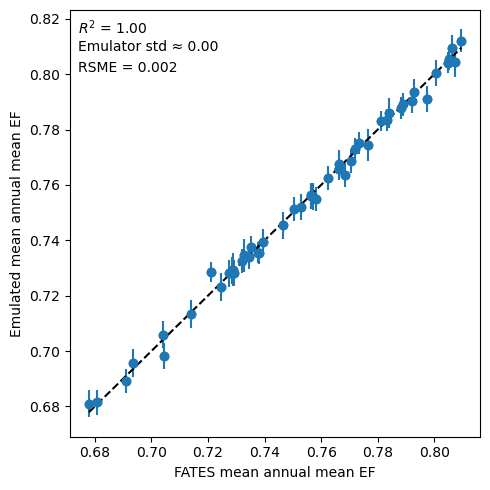

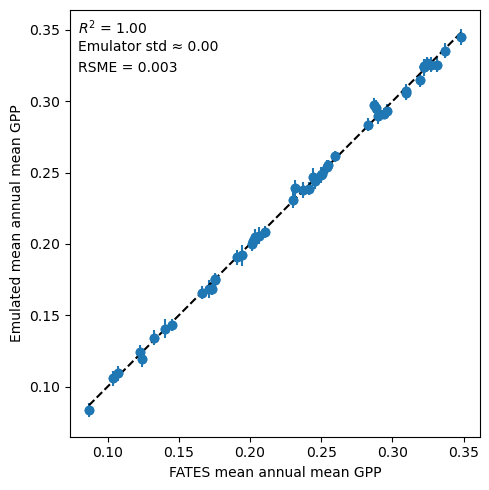

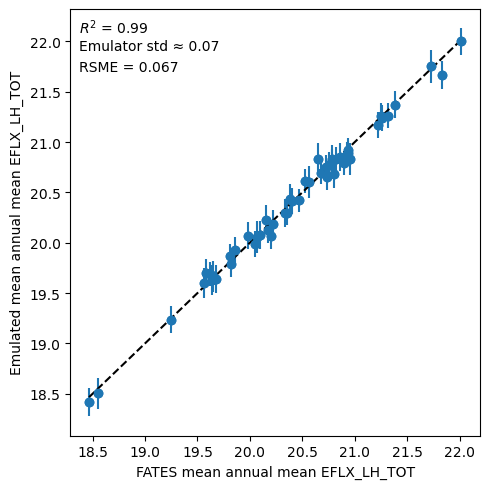

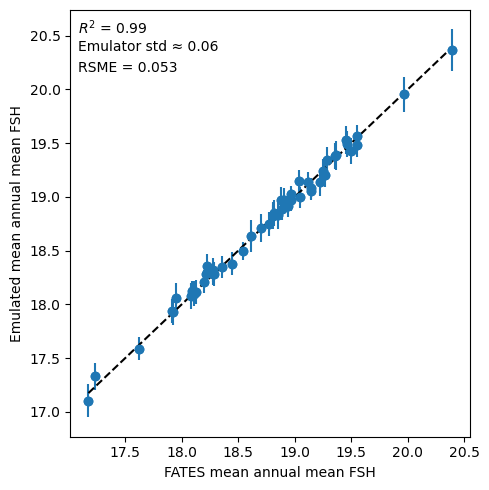

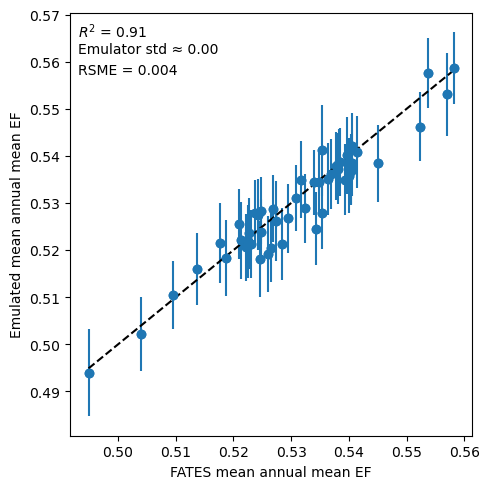

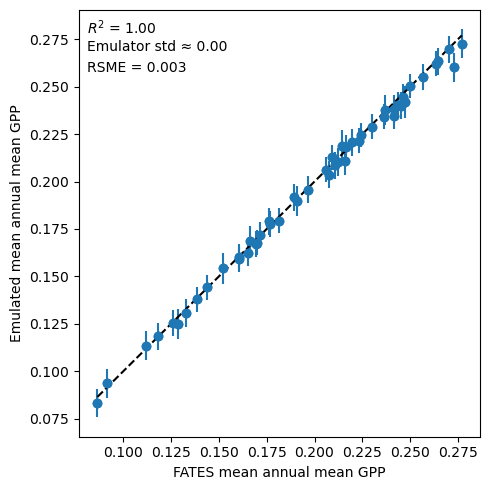

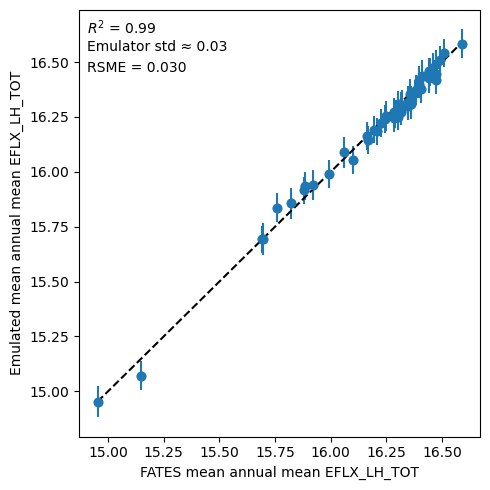

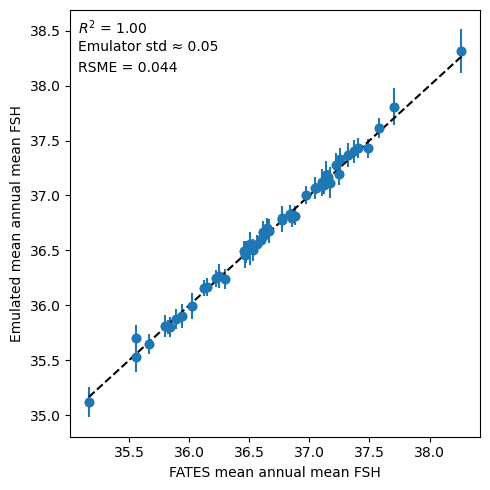

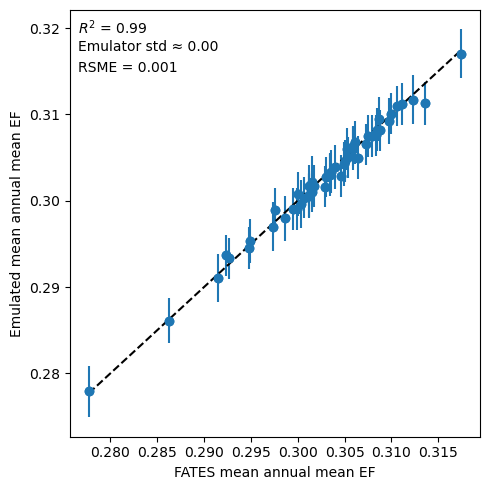

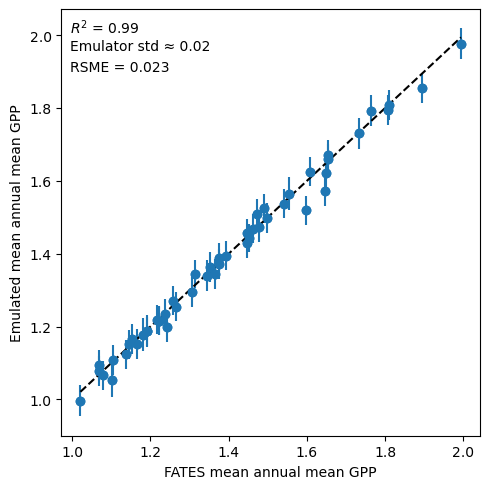

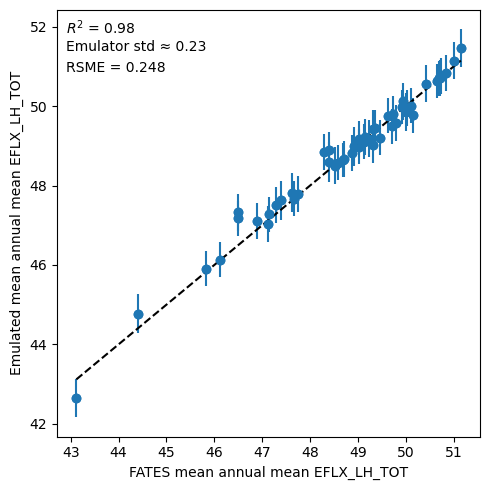

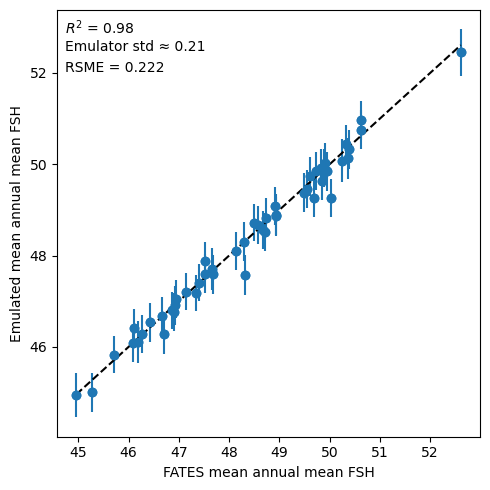

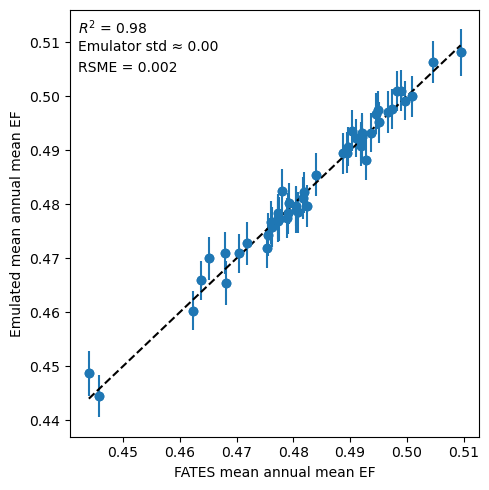

In [8]:
r2_dict = {}
rmse_dict = {}
sd_dict = {}
for pft in ens_dict[ensemble]['pfts']:

    pft_name = all_pfts[pft-1]
    pft_id = pft_ids[pft_name]

    r2_dict[pft_name] = {}
    rmse_dict[pft_name] = {}
    sd_dict[pft_name] = {}

    # get the gridcells for this PFT
    pft_grid = clm.get_pft_grids(ens_dict[ensemble]['land_mask_file'],
                             ens_dict[ensemble]['mesh_file'], pft)

    # subset the ensemble for just this pft
    pft_ens = clm.get_pft_ensemble(ens_dict[ensemble]['ensemble_file'],
                                   pft_grid, land_frac_ds_file, surdat)

    # get rid of lakes
    pft_ens = pft_ens.where(pft_ens.land_frac > 0.99, drop=True)
    if pft != 12:
        pft_ens = pft_ens.where(pft_ens.pct_lake < 30.0, drop=True)

    for variable in calibration_vars:
        # calculate area-weighted mean for this variable
        pft_mean = clm.weighted_mean(pft_ens, variable)

        # split into testing and training datasets
        X_test, X_train, y_test, y_train = em.split_dataset(pft_mean, lhc_key,
                                                            n_test)

        # select best kernel for gp emulator
        kernel = em.select_kernel(gp_kernels, X_train, X_test, y_train, y_test, variable)

        # save to file
        fig_file = os.path.join(fig_dir, 'emulator_figs',
                                f"{pft_id}_{variable}_emulator_validation.png")
        save_dir = os.path.join(emulator_dir, f"{pft_id}_{variable}")
        r2, rmse, sd = em.train_val_save(X_train, X_test, y_train, y_test, kernel, variable,
                                   out_file=fig_file, save_dir=save_dir)

        # save the r2, rmse, and sd
        r2_dict[pft_name][f'r2_{variable}'] = r2
        rmse_dict[pft_name][f'rmse_{variable}'] = rmse
        sd_dict[pft_name][f'sd_{variable}'] = sd

In [22]:
r2_vals = pd.DataFrame.from_dict(r2_dict, orient='index')
r2_vals['pft'] = r2_vals.index
rmse_vals = pd.DataFrame.from_dict(rmse_dict, orient='index')
rmse_vals['pft'] = rmse_vals.index
sd_vals = pd.DataFrame.from_dict(sd_dict, orient='index')
sd_vals['pft'] = sd_vals.index

df = r2_vals.merge(rmse_vals, on='pft').merge(sd_vals, on='pft')
df.to_csv(os.path.join(emulator_dir, f'emulator_validation_{ensemble}.csv'))